<a href="https://colab.research.google.com/github/Daniellopezram/Machine-Learning/blob/main/Unidad%202/Proyecto_caso5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo
* El objetivo de esta práctica es que el estudiante demuestre su capacidad para seleccionar, implementar, comparar y optimizar diversos algoritmos de Machine Learning aplicados a problemas de regresión en entornos reales. Se enfatiza el uso de herramientas de
vanguardia como la IA Generativa para la toma de decisiones y el uso de GitHub para la
gestión de proyectos de software.

En el Data set se encuentra informacion relevante a pesticidas

Unidad 2 Modelos de Regresion

Integrantes:

Oscar Andres Torres Loera

Daniel Eduardo Lopez Ramirez


Facilitador:

Dr. Jose Gabriel



## Paso 1. Cargar el Data set ##

In [ ]:
# Se cargaran las bibliotecas y el Data set a maenejar (el 5)
# --- LIBRERÍAS BASE Y MANEJO DE DATOS ---
import pandas as pd
import numpy as np
import time  # NUEVO: Para medir el tiempo de ejecución en milisegundos

# --- PREPROCESAMIENTO Y MODELACIÓN ---
from sklearn.model_selection import train_test_split, GridSearchCV # NUEVO: Agregamos GridSearchCV para la Fase III
from sklearn.preprocessing import StandardScaler

# --- MODELOS DE MACHINE LEARNING ---
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# --- MÉTRICAS DE EVALUACIÓN ---
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # NUEVO: Agregamos el MAE para la tabla
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

# --- CARGA DE DATOS ---
df = pd.read_csv("pesticides.csv")

# Mostrar las primeras filas
df.head(5)

,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


##Fase I: Exploración y Comprensión del Dominio (EDA)
Antes de comenzar con el análisis estadístico y visual, es fundamental limpiar nuestro conjunto de datos. Observamos que las columnas Domain, Element, Item y Unit contienen valores constantes para todos los registros (por ejemplo, "Pesticides Use" o "tonnes of active ingredients").

En Machine Learning, las variables que no cambian (varianza cero) no aportan patrones útiles para predecir nuestra variable objetivo (Value). Por lo tanto, reduciremos nuestro dataset únicamente a las variables que nos interesan: Area, Year y Value.

In [ ]:
# Filtramos solo las columnas útiles y eliminamos posibles valores nulos
df_clean = df[['Area', 'Year', 'Value']].copy()
df_clean = df_clean.dropna()

print("Forma del dataset limpio:", df_clean.shape)
display(df_clean.head())

Forma del dataset limpio: (4349, 3)


,Area,Year,Value
0,Albania,1990,121.0
1,Albania,1991,121.0
2,Albania,1992,121.0
3,Albania,1993,121.0
4,Albania,1994,201.0


### 1. Análisis Estadístico
A continuación, generamos un resumen de las medidas de tendencia central y dispersión para nuestras variables numéricas (Year y Value), así como un conteo de nuestros datos categóricos (Area).

In [ ]:
# Estadísticas de variables numéricas (Año y Valor)
print("--- Estadísticas de Variables Numéricas ---")
display(df_clean.describe())

# Estadísticas de la variable categórica (Área/País)
print("\n--- Estadísticas de Variable Categórica ---")
display(df_clean.describe(include=['object', 'O']))

--- Estadísticas de Variables Numéricas ---


,Year,Value
count,4349.000000,4.349000e+03
mean,2003.138883,2.030334e+04
std,7.728044,1.177362e+05
min,1990.000000,0.000000e+00
25%,1996.000000,9.300000e+01
50%,2003.000000,1.137560e+03
75%,2010.000000,7.869000e+03
max,2016.000000,1.807000e+06



--- Estadísticas de Variable Categórica ---


,Area
count,4349
unique,168
top,Albania
freq,27


### 2. Análisis de Tendencias y Valores Atípicos (Outliers)
Para observar el comportamiento de los datos y detectar posibles valores atípicos (como pide la rúbrica), utilizaremos gráficos de dispersión y diagramas de caja (Boxplots). Dado que hay muchos países, el Boxplot nos ayudará a ver claramente qué registros tienen un uso de pesticidas anormalmente alto en comparación con el resto del mundo.

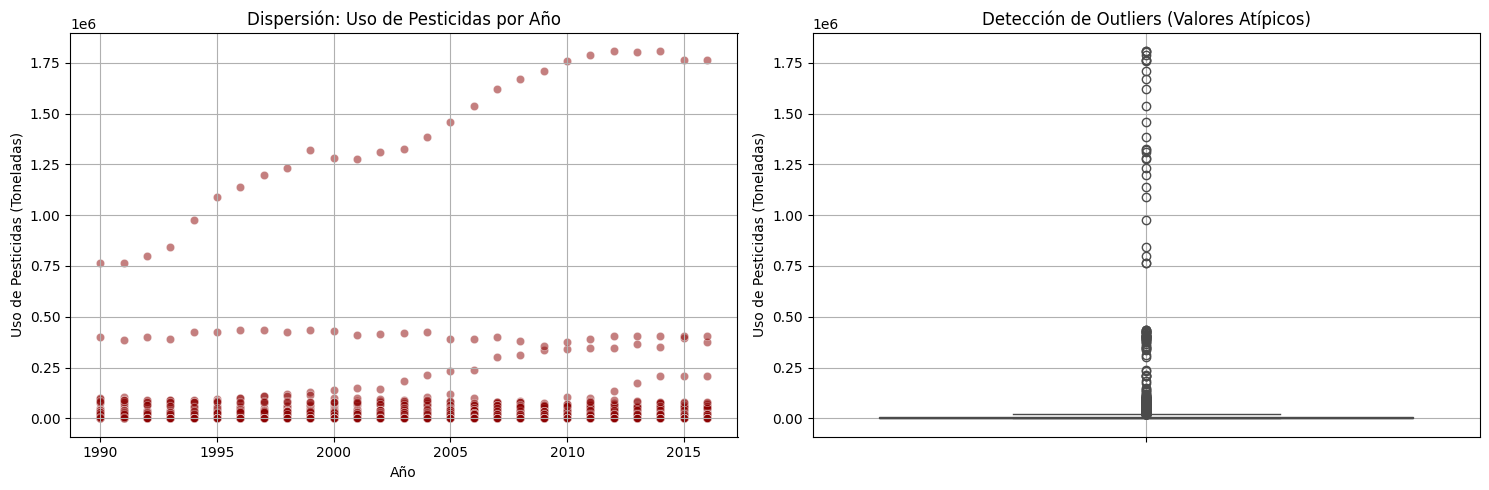

In [ ]:
plt.figure(figsize=(15, 5))

# Gráfico 1: Dispersión del uso de pesticidas a lo largo de los años
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_clean, x='Year', y='Value', alpha=0.5, color='darkred')
plt.title('Dispersión: Uso de Pesticidas por Año')
plt.xlabel('Año')
plt.ylabel('Uso de Pesticidas (Toneladas)')
plt.grid(True)

# Gráfico 2: Diagrama de caja para detectar Outliers generales
plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, y='Value', color='steelblue')
plt.title('Detección de Outliers (Valores Atípicos)')
plt.ylabel('Uso de Pesticidas (Toneladas)')
plt.grid(True)

plt.tight_layout()
plt.show()

# (Opcional) Gráfico interactivo con Plotly para explorar países específicos
# Descomenta las siguientes dos líneas si quieres interactuar con el gráfico:
fig = px.scatter(df_clean, x='Year', y='Value', color='Area', title='Tendencia Interactiva por País')
fig.show()

### 3. Visualización de Correlaciones (Heatmap)
La correlación de Pearson requiere variables numéricas. Dado que Area es texto, los algoritmos tradicionales de correlación fallarían. Para solucionar esto y cumplir con el requerimiento del mapa de calor, aplicaremos temporalmente un LabelEncoder a la columna Area. Esto le asignará un número único a cada país, permitiéndonos ver matemáticamente cómo se relaciona el país y el año con la cantidad de pesticidas utilizados.

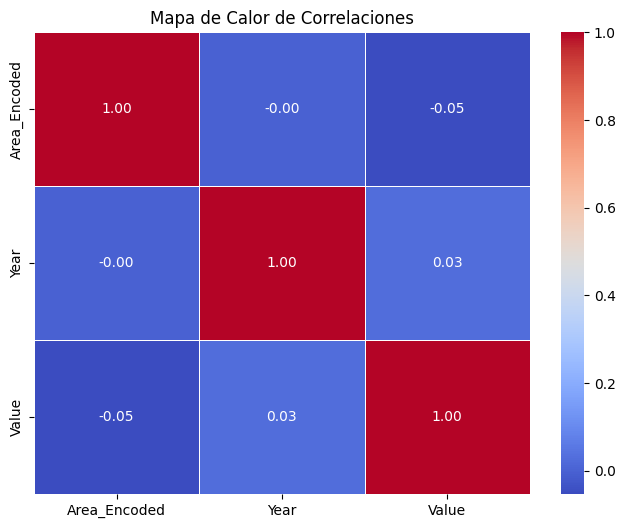

In [ ]:
# Creamos una copia para no alterar el dataset original que usaremos en los modelos
df_corr = df_clean.copy()

# Codificamos los países a números
le = LabelEncoder()
df_corr['Area_Encoded'] = le.fit_transform(df_corr['Area'])

# Calculamos la matriz de correlación
matriz_correlacion = df_corr[['Area_Encoded', 'Year', 'Value']].corr()

# Generamos el Mapa de Calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

#Fase II: Implementación de Modelos (Baseline)

## 1. Preparación de los Datos y Función de Evaluación
Primero, prepararemos los datos (One-Hot Encoding y división 80/20). También definiremos una función que nos permitirá evaluar y graficar cada modelo individualmente sin tener que repetir el mismo código de las gráficas 5 veces.

In [ ]:
# --- PREPARACIÓN DE DATOS ---
# Convertimos la columna 'Area' (texto) en columnas de 0s y 1s
df_model = pd.get_dummies(df_clean, columns=['Area'], drop_first=True)

# Separamos variables independientes (X) y objetivo (y)
X = df_model.drop('Value', axis=1)
y = df_model['Value']

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos para entrenar: {X_train.shape[0]} filas")
print(f"Datos para probar: {X_test.shape[0]} filas")

# --- ESCALAMIENTO (Para SVR) ---
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# Lista global para guardar los resultados
resultados_fase2 = []

# --- FUNCIÓN DE EVALUACIÓN Y GRÁFICAS ---
def evaluar_modelo(y_real, y_pred, nombre_modelo, tiempo):
    # Calcular métricas
    r2 = r2_score(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    # Guardar en la lista
    resultados_fase2.append({
        "Algoritmo": nombre_modelo,
        "R2 Score": round(r2, 4),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "Tiempo de Ejecución (ms)": round(tiempo, 2)
    })

    # Graficar
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.kdeplot(y_real, label='Real', ax=axes[0], color='tab:blue', linewidth=2)
    sns.kdeplot(y_pred, label='Predicho', ax=axes[0], color='tab:orange', linestyle='--', linewidth=2)
    axes[0].set_title(f"{nombre_modelo}: Distribución")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].scatter(y_real, y_pred, color='darkred', alpha=0.6)
    min_v, max_v = min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())
    axes[1].plot([min_v, max_v], [min_v, max_v], 'b--', linewidth=2, label='Línea Ideal')
    axes[1].set_title(f"{nombre_modelo}: Dispersión")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    print(f"✅ R2: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | Tiempo: {tiempo:.2f} ms\n")

Datos para entrenar: 3479 filas
Datos para probar: 870 filas


### Modelo 1: Regresión Lineal Múltiple

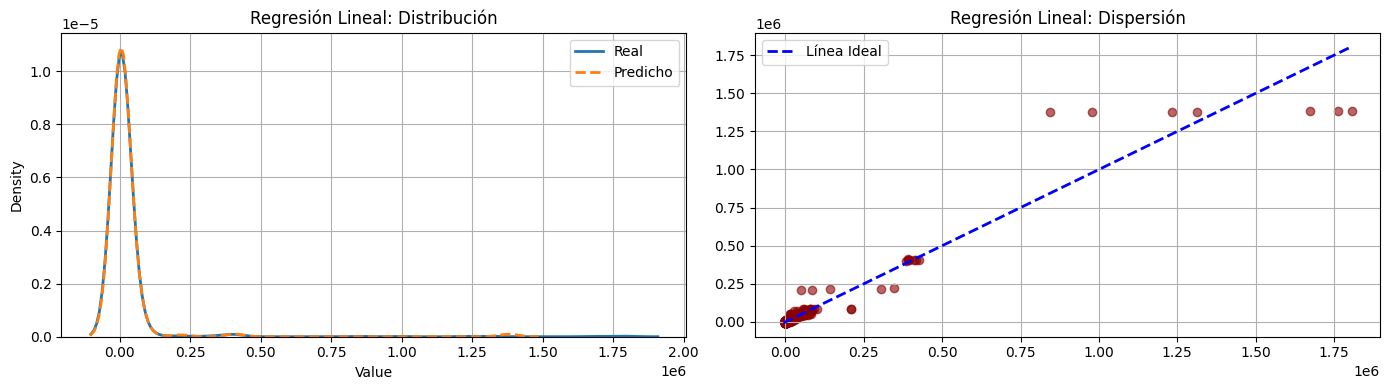

✅ R2: 0.9345 | MAE: 7492.42 | RMSE: 33948.79 | Tiempo: 63.06 ms



In [ ]:
modelo_lr = LinearRegression()

inicio = time.time()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)
tiempo_lr = (time.time() - inicio) * 1000

evaluar_modelo(y_test, y_pred_lr, "Regresión Lineal", tiempo_lr)

### Modelo 2: Árbol de Decisión

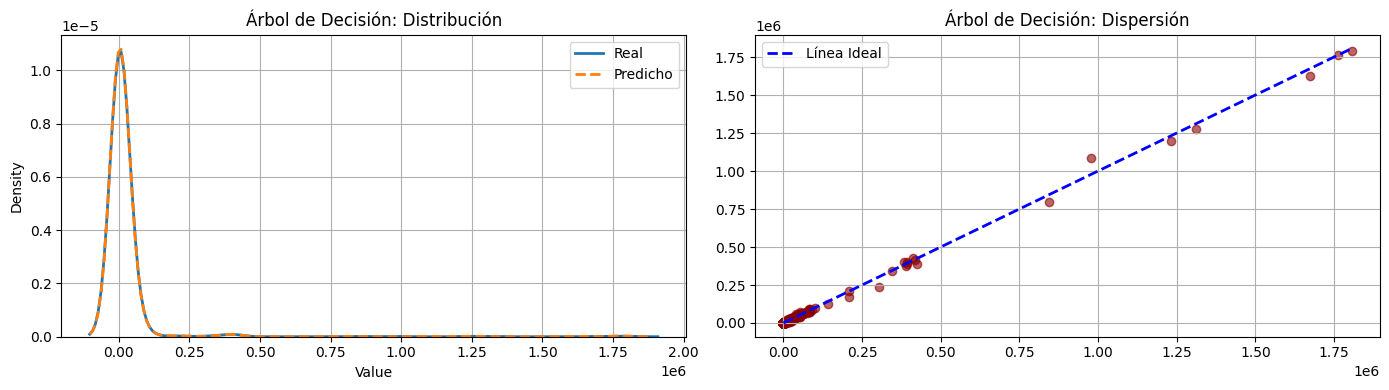

✅ R2: 0.9980 | MAE: 1334.81 | RMSE: 6001.47 | Tiempo: 147.85 ms



In [ ]:
modelo_dt = DecisionTreeRegressor(random_state=42)

inicio = time.time()
modelo_dt.fit(X_train, y_train)
y_pred_dt = modelo_dt.predict(X_test)
tiempo_dt = (time.time() - inicio) * 1000

evaluar_modelo(y_test, y_pred_dt, "Árbol de Decisión", tiempo_dt)

### Modelo 3: Random Forest

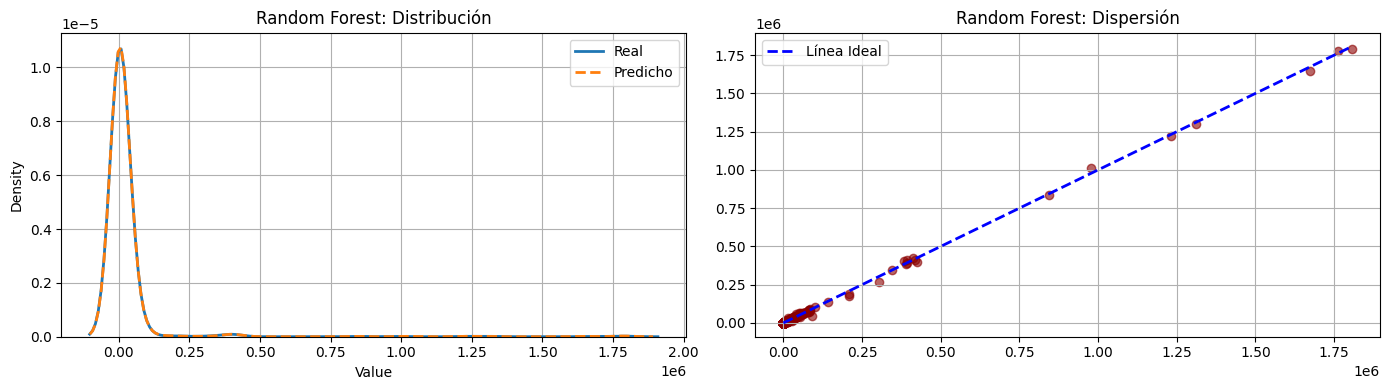

✅ R2: 0.9992 | MAE: 1051.63 | RMSE: 3713.28 | Tiempo: 10401.05 ms



In [ ]:
modelo_rf = RandomForestRegressor(random_state=42)

inicio = time.time()
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)
tiempo_rf = (time.time() - inicio) * 1000

evaluar_modelo(y_test, y_pred_rf, "Random Forest", tiempo_rf)

### Modelo 4: SVR (Support Vector Regression)

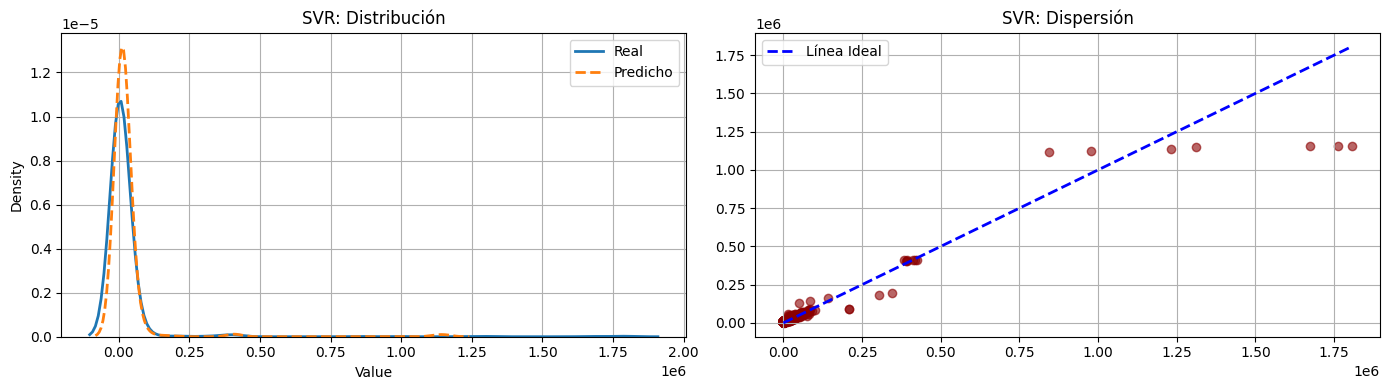

✅ R2: 0.9129 | MAE: 11855.60 | RMSE: 39140.97 | Tiempo: 230.81 ms



In [ ]:
modelo_svr = SVR()

inicio = time.time()
modelo_svr.fit(X_train_scaled, y_train_scaled)
y_pred_scaled = modelo_svr.predict(X_test_scaled)
tiempo_svr = (time.time() - inicio) * 1000

# Desescalamos las predicciones para obtener el error real
y_pred_svr = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

evaluar_modelo(y_test, y_pred_svr, "SVR", tiempo_svr)

### Modelo 5: XGBoost

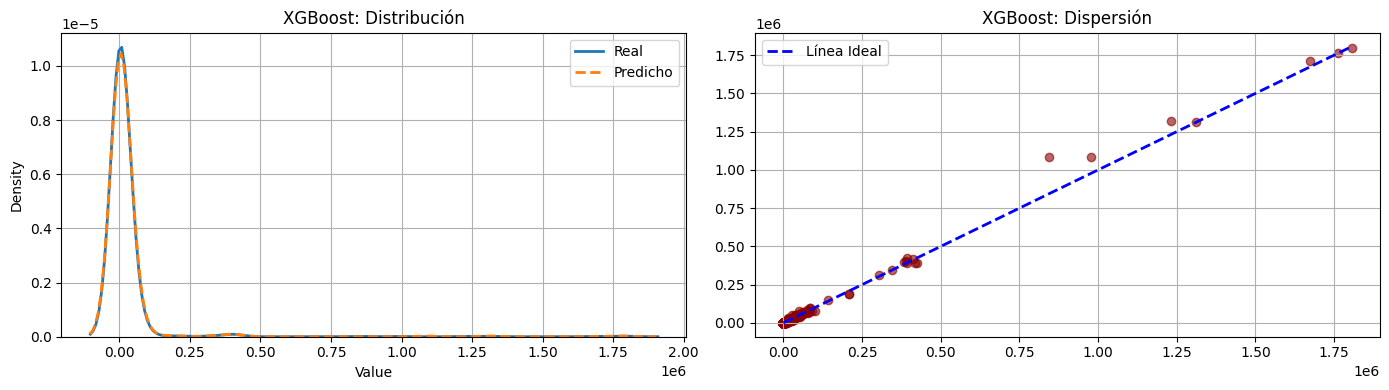

✅ R2: 0.9941 | MAE: 2351.13 | RMSE: 10187.03 | Tiempo: 298.98 ms



In [ ]:
modelo_xgb = XGBRegressor(random_state=42)

inicio = time.time()
modelo_xgb.fit(X_train, y_train)
y_pred_xgb = modelo_xgb.predict(X_test)
tiempo_xgb = (time.time() - inicio) * 1000

evaluar_modelo(y_test, y_pred_xgb, "XGBoost", tiempo_xgb)

##3. Tabla Comparativa de Rendimiento (Baseline)

In [ ]:
# Creamos el DataFrame con los resultados
tabla_baseline = pd.DataFrame(resultados_fase2)

# Ordenamos la tabla: Principalmente por 'R2 Score' (descendente) y 'RMSE' (ascendente)
tabla_baseline_ordenada = tabla_baseline.sort_values(by=['R2 Score', 'RMSE'], ascending=[False, True])

# Reiniciamos los índices para estética
tabla_baseline_ordenada = tabla_baseline_ordenada.reset_index(drop=True)

print("--- Tabla Comparativa: Modelos Baseline (Fase II) ---")
display(tabla_baseline_ordenada)

--- Tabla Comparativa: Modelos Baseline (Fase II) ---


,Algoritmo,R2 Score,MAE,RMSE,Tiempo de Ejecución (ms)
0,Random Forest,0.9992,1051.63,3713.28,10401.05
1,Árbol de Decisión,0.9980,1334.81,6001.47,147.85
2,XGBoost,0.9941,2351.13,10187.03,298.98
3,Regresión Lineal,0.9345,7492.42,33948.79,63.06
4,SVR,0.9129,11855.60,39140.97,230.81


#Fase 3. Comparacion con una Inteligencia Artificial Generativa #

* Bueno aqui en este apartado, se opto por usar la IAG llamada Julius ai, la cual cuenta con un modelo de inteligencia artificial mas que nada enfocado en la estadistica pura por lo cual se cree es ideal para analizar correctamente estos datos de manera objetiva.



primero recibio el data set para que lo cargara y analizara por su cuenta, teniendo en cuenta las librerias y el entorno en cuestion, tambien se le indico las variables objetivo para evitar repetir ciclos.

      Area  Year  Value
0  Albania  1990  121.0
1  Albania  1991  121.0
2  Albania  1992  121.0
3  Albania  1993  121.0
4  Albania  1994  201.0
           Area         Year         Value
count      4349  4349.000000  4.349000e+03
unique      168          NaN           NaN
top     Albania          NaN           NaN
freq         27          NaN           NaN
mean        NaN  2003.138883  2.030334e+04
std         NaN     7.728044  1.177362e+05
min         NaN  1990.000000  0.000000e+00
25%         NaN  1996.000000  9.300000e+01
50%         NaN  2003.000000  1.137560e+03
75%         NaN  2010.000000  7.869000e+03
max         NaN  2016.000000  1.807000e+06


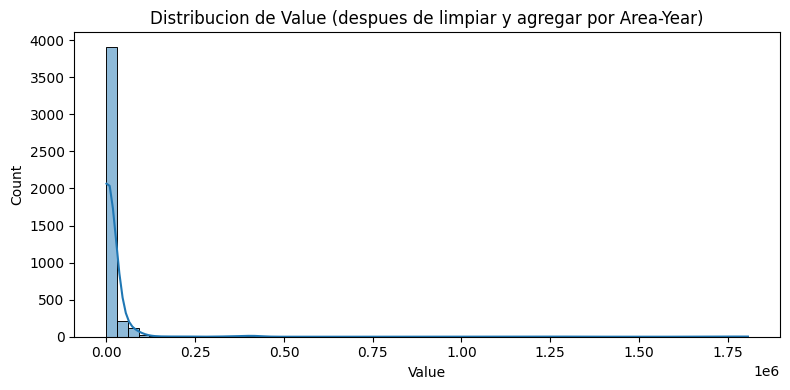

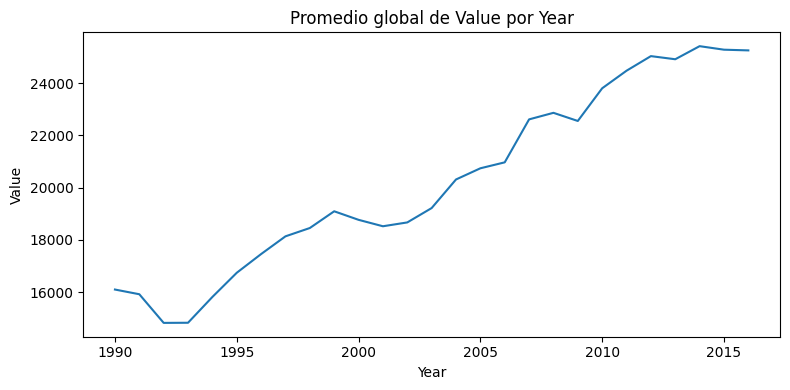

In [ ]:
# Load (if needed), clean to the 3 variables of interest: Area, Year, Value; basic cleaning and quick EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df
except Exception:
    df = pd.read_csv('pesticides.csv', encoding='utf-8')

pest_df = df.copy()

# Keep only the 3 variables the user cares about
pest_df = pest_df[['Area','Year','Value']].copy()

# Coerce types and drop unusable rows
pest_df['Year'] = pd.to_numeric(pest_df['Year'], errors='coerce')
pest_df['Value'] = pd.to_numeric(pest_df['Value'], errors='coerce')
pest_df['Area'] = pest_df['Area'].astype(str).str.strip()

pest_df = pest_df.dropna(subset=['Area','Year','Value']).copy()

# Remove obviously invalid years (assumption: data should be between 1960 and 2100)
pest_df = pest_df[(pest_df['Year'] >= 1960) & (pest_df['Year'] <= 2100)].copy()

# Aggregate in case there are duplicates for the same Area-Year
pest_df_agg = pest_df.groupby(['Area','Year'], as_index=False)['Value'].mean()

print(pest_df_agg.head())
print(pest_df_agg.describe(include='all'))

plt.figure(figsize=(8,4))
sns.histplot(pest_df_agg['Value'], bins=60, kde=True)
plt.title('Distribucion de Value (despues de limpiar y agregar por Area-Year)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
sns.lineplot(data=pest_df_agg.groupby('Year', as_index=False)['Value'].mean(), x='Year', y='Value')
plt.title('Promedio global de Value por Year')
plt.tight_layout()
plt.show()

Aqui se entreno los modelos para que actuaran basado en los datos de area y año para predecir las toneladas, con los datos previamente limpiados de las otras variables que no se iban a utilizar.

              Modelo        R2          MAE          RMSE     Fit (ms)  \
0      Random Forest  0.998164   821.778287   3076.811853  9490.367363   
1  Arbol de decision  0.997167   990.029839   3822.310704    67.125049   
2   Regresion lineal  0.934793  5870.908815  18338.049858    35.279787   

    Pred (ms)  
0  248.447293  
1    5.856416  
2    5.725155  


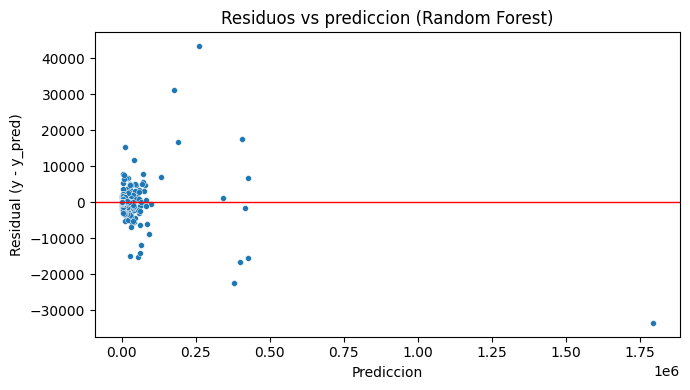

In [ ]:
# Train/test evaluation using only Area + Year to predict Value (cleaned/aggregated)
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

X_simple = pest_df_agg[['Area','Year']].copy()
y_simple = pest_df_agg['Value'].copy()

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

preprocess_simple = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Area']),
        ('num', 'passthrough', ['Year'])
    ]
)

models_simple = {
    'Regresion lineal': LinearRegression(),
    'Arbol de decision': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
}

rows_simple = []
for model_name, model_obj in models_simple.items():
    pipe_obj = Pipeline(steps=[('prep', preprocess_simple), ('model', model_obj)])

    t0_fit = time.perf_counter()
    pipe_obj.fit(X_train_s, y_train_s)
    t1_fit = time.perf_counter()

    t0_pred = time.perf_counter()
    y_pred_s = pipe_obj.predict(X_test_s)
    t1_pred = time.perf_counter()

    r2_val = r2_score(y_test_s, y_pred_s)
    mae_val = mean_absolute_error(y_test_s, y_pred_s)
    rmse_val = float(np.sqrt(mean_squared_error(y_test_s, y_pred_s)))

    rows_simple.append({
        'Modelo': model_name,
        'R2': r2_val,
        'MAE': mae_val,
        'RMSE': rmse_val,
        'Fit (ms)': (t1_fit - t0_fit) * 1000.0,
        'Pred (ms)': (t1_pred - t0_pred) * 1000.0
    })

simple_results_df = pd.DataFrame(rows_simple).sort_values('R2', ascending=False).reset_index(drop=True)
print(simple_results_df)

# Residual plot for best model
best_model_name = simple_results_df.loc[0, 'Modelo']
best_model_obj = models_simple[best_model_name]
best_pipe = Pipeline(steps=[('prep', preprocess_simple), ('model', best_model_obj)])
best_pipe.fit(X_train_s, y_train_s)
best_pred = best_pipe.predict(X_test_s)
residuals = y_test_s.values - best_pred

plt.figure(figsize=(7,4))
sns.scatterplot(x=best_pred, y=residuals, s=18)
plt.axhline(0, color='red', linewidth=1)
plt.title('Residuos vs prediccion (' + best_model_name + ')')
plt.xlabel('Prediccion')
plt.ylabel('Residual (y - y_pred)')
plt.tight_layout()
plt.show()

La i.a no puso tantos graficos sin embargo su analisis demostro similitud con los resultados que ya teniamos mas o menos, para terminar saco un resumen expres de los datos para contestar a las preguntas, cabe destacar que es buena herramienta para analisis estadistico.

In [ ]:
# Evaluate less-biased splits: temporal split and group split by Area, using only Area+Year -> Value
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit

X_simple = pest_df_agg[['Area','Year']].copy()
y_simple = pest_df_agg['Value'].copy()

preprocess_simple = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Area']),
        ('num', 'passthrough', ['Year'])
    ]
)

models_simple = {
    'Regresion lineal': LinearRegression(),
    'Arbol de decision': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
}

def eval_split(X_train, X_test, y_train, y_test):
    rows_local = []
    for model_name, model_obj in models_simple.items():
        pipe_obj = Pipeline(steps=[('prep', preprocess_simple), ('model', model_obj)])
        pipe_obj.fit(X_train, y_train)
        y_pred = pipe_obj.predict(X_test)
        rows_local.append({
            'Modelo': model_name,
            'R2': r2_score(y_test, y_pred),
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred)))
        })
    return pd.DataFrame(rows_local).sort_values('R2', ascending=False).reset_index(drop=True)

# Temporal split: train <= 2010, test > 2010 (assumption)
cut_year = 2010
train_mask = X_simple['Year'] <= cut_year
test_mask = X_simple['Year'] > cut_year
X_train_t = X_simple.loc[train_mask]
y_train_t = y_simple.loc[train_mask]
X_test_t = X_simple.loc[test_mask]
y_test_t = y_simple.loc[test_mask]

temporal_results_df = eval_split(X_train_t, X_test_t, y_train_t, y_test_t)
print(temporal_results_df)

# Group split by Area: hold out 20 percent of Areas
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_simple, y_simple, groups=X_simple['Area']))
X_train_g = X_simple.iloc[train_idx]
y_train_g = y_simple.iloc[train_idx]
X_test_g = X_simple.iloc[test_idx]
y_test_g = y_simple.iloc[test_idx]

group_results_df = eval_split(X_train_g, X_test_g, y_train_g, y_test_g)
print(group_results_df)

# Save for later reference in narrative
cut_year_val = cut_year
n_train_temp = int(X_train_t.shape[0])
n_test_temp = int(X_test_t.shape[0])
n_train_group = int(X_train_g.shape[0])
n_test_group = int(X_test_g.shape[0])
unique_areas_train = int(X_train_g['Area'].nunique())
unique_areas_test = int(X_test_g['Area'].nunique())

print(n_train_temp)
print(n_test_temp)
print(n_train_group)
print(n_test_group)
print(unique_areas_train)
print(unique_areas_test)

              Modelo        R2           MAE          RMSE
0  Arbol de decision  0.996162   2582.644100   9050.392183
1      Random Forest  0.994636   2988.623701  10700.012980
2   Regresion lineal  0.903536  12506.151605  45374.139299
              Modelo        R2           MAE          RMSE
0      Random Forest -0.213791  10103.226811  24071.007069
1  Arbol de decision -0.213811  10103.667724  24071.204238
2   Regresion lineal -0.368656  22329.094465  25560.507499
3371
978
3457
892
134
34


###Preguntas que se le hicieron a la IAG
* ¿Qué variables son las más relevantes?

si tu objetivo es entender/predict tendencia por país, quedarte con Area + Year para predecir Value es lo más limpio y defendible. Todo lo demás (Domain, Item, Unit, etc.) mete mucha “información contextual” que puede inflar métricas y no siempre es lo que quieres modelar.

* ¿Qué modelo funciona mejor?

Depende de cómo evalúas (esto es clave, porque ahí aparece el sesgo).

Con un split “normal” aleatorio, Random Forest sale top (R2 ~ 0.998). Peeero ese escenario es muy optimista porque el modelo ve el mismo país tanto en train como en test y “recuerda” su nivel típico.
Cuando lo haces más realista, la historia cambia

* ¿Cuál funciona mejor sin tanto sesgo de información?
Aquí lo más importante no es solo el modelo, sino el tipo de partición (split).

Escenario A: Split temporal (train años viejos, test años nuevos)
Hice train <= 2010 y test > 2010 usando solo Area y Year.

En este caso, el mejor fue Árbol de decisión:

Árbol de decisión: R2 ≈ 0.9962
Random Forest: R2 ≈ 0.9946
Regresión lineal: R2 ≈ 0.9035
Interpretación: si el país ya existe en entrenamiento y solo estás “yendo al futuro”, árbol/random forest funcionan muy bien. Aquí hay menos sesgo que en aleatorio, pero todavía el modelo se apoya fuerte en saber “qué país es”.


#Fase 4 Conclusiones
* Despues de comparar los resultados y el modelo elegido por nosotros y por la IAG julius llegamos a la conclusion de que el metodo mejor votado para esta ocacion fue el de Random Forest porque si bien es cierto que es optimista pero bueno hay que hacer lo que se puede con los datos que se proporcionan ademas los datos son igual lanzados del data set, pero no deben ser erroneos pues si es verdad que china es de los paises que mas contaminan y segun los datos es por lejos el mayor contaminante al menos hablando de pesticidas porque puede haber otros factores o sustancias que este set de datos no contempla por lo que si bien china es grande esa cantidad de poblacion es la que sugiere que por esa misma razon es de los mas contaminantes.